# IMPORTING FILES AND READING CSV

In [7]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv


In [4]:
import pandas as pd

In [8]:
df_sentiment = pd.read_csv('fear_greed_index.csv')
df_trader = pd.read_csv('historical_data.csv')

# SENTIMENT DATA CLEANING

### Checking columns

In [9]:
df_sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

### Cleaning data and conversion of date

In [10]:
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])
df_sentiment.rename(columns={
    'date': 'Date',
    'classification': 'Classification',
    'value': 'Value',
    'timestamp' : 'Timestamp'
}, inplace=True)
df_sentiment['Date'] = df_sentiment['Date'].dt.date

In [11]:
df_sentiment['Classification'].value_counts()

,count
Classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


In [12]:
df_sentiment['Classification'] = df_sentiment['Classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

In [13]:
df_sentiment['Classification'].value_counts()

,count
Classification,
Fear,1289
Greed,959
Neutral,396


### Checking for Null and messy values to remove them

In [14]:
df_sentiment.isnull().sum()

,0
Timestamp,0
Value,0
Classification,0
Date,0


In [15]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Timestamp       2644 non-null   int64 
 1   Value           2644 non-null   int64 
 2   Classification  2644 non-null   object
 3   Date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


# TRADER DATA CLEANING

### Checking for Null Values

In [16]:
df_trader.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


### Checking for duplicates

In [17]:
df_trader.duplicated().sum()

np.int64(0)

### Updating column names properly

In [18]:
print(df_trader.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [19]:
df_trader.columns = df_trader.columns.str.strip().str.lower().str.replace(' ', '_')

In [20]:
df_trader.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [21]:
df_trader = df_trader.drop_duplicates()

### Conversion of Date and timestamps

In [22]:
df_trader['timestamp_ist'] = pd.to_datetime(df_trader['timestamp_ist'], errors='coerce')
df_trader = df_trader.dropna(subset=['timestamp_ist'])
df_trader['Date'] = df_trader['timestamp_ist'].dt.date

In [23]:
df_trader[['timestamp_ist', 'Date', 'closed_pnl']].head()

,timestamp_ist,Date,closed_pnl
0,2024-02-12 22:50:00,2024-02-12,0.0
1,2024-02-12 22:50:00,2024-02-12,0.0
2,2024-02-12 22:50:00,2024-02-12,0.0
3,2024-02-12 22:50:00,2024-02-12,0.0
4,2024-02-12 22:50:00,2024-02-12,0.0


# MERGING DATASETS

In [24]:
df = pd.merge(df_trader, df_sentiment[['Date', 'Classification']], on='Date', how='left')

In [26]:
df['Classification'].value_counts(dropna=False)

,count
Classification,
NaN,43361
Greed,16913
Fear,16195
Neutral,2756


In [27]:
df = df.dropna(subset=['Classification'])

In [28]:
df['Classification'].value_counts()

,count
Classification,
Greed,16913
Fear,16195
Neutral,2756


In [29]:
df.to_csv('merged_data.csv', index=False)

In [31]:
files.download('merged_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ANALYSIS & METRICS


In [45]:
df = df[df['Classification'] != 'Neutral']

### Analysis 1: Profitability under Different Market Sentiment

This analysis examines how trader profitability (PnL) varies between Fear and Greed market conditions.

In [46]:
df.groupby('Classification')['closed_pnl'].mean()

,closed_pnl
Classification,
Fear,110.134333
Greed,104.447834


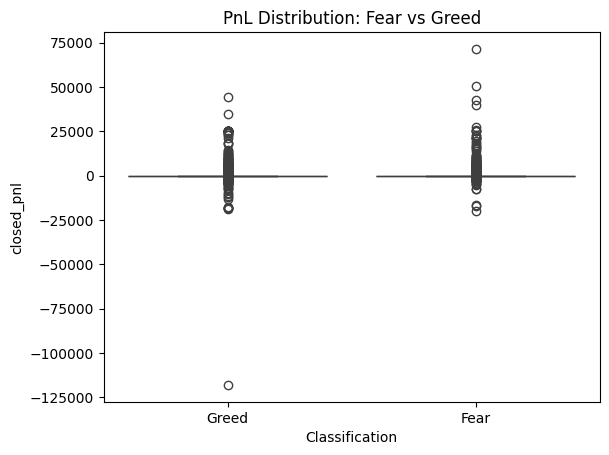

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Classification', y='closed_pnl', data=df)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

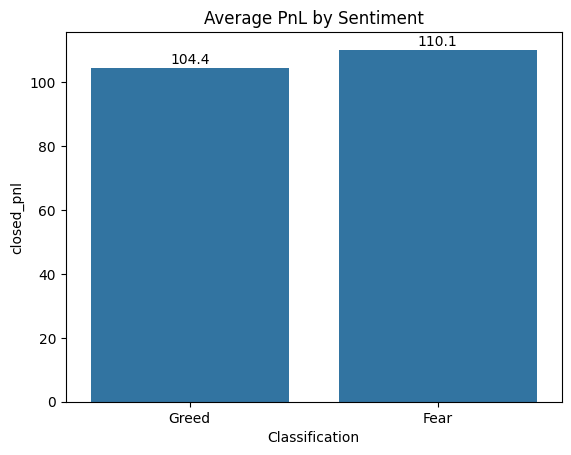

In [64]:
ax = sns.barplot(x='Classification', y='closed_pnl', data=df, errorbar=None)

plt.title("Average PnL by Sentiment")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f',padding=1)

plt.show()

**Observation:**
Traders show slightly higher average PnL during Fear compared to Greed.

**Interpretation:**
This suggests that traders take fewer but higher conviction trades during Fear, leading to larger profits per trade.

### Analysis 2: Win Rate Comparison

This analysis evaluates whether traders are more consistently profitable during Fear or Greed periods.


In [37]:
df['win'] = df['closed_pnl'] > 0
df.groupby('Classification')['win'].mean()

,win
Classification,
Fear,0.369003
Greed,0.474783
Neutral,0.494920


**Observation:**
Win rate is higher during Greed compared to Fear.

**Interpretation:**
This indicates traders experience more frequent small wins during Greed, but not necessarily higher overall profitability.

### Analysis 3: Trade Size Behavior

This analysis explores how traders adjust their position sizes under different market sentiment conditions.

In [49]:
df.groupby('Classification')['size_usd'].mean()

,size_usd
Classification,
Fear,5511.246132
Greed,4450.397683


**Observation:**
Average trade size is higher during Fear compared to Greed.

**Interpretation:**
This suggests traders place fewer but larger trades during Fear, indicating higher conviction.

### Analysis 4: Trading Direction Bias

This analysis investigates whether traders prefer buying or selling during Fear and Greed phases.

In [41]:
pd.crosstab(df['Classification'], df['side'], normalize='index')

side,BUY,SELL
Classification,,
Fear,0.523310,0.476690
Greed,0.417903,0.582097
Neutral,0.370102,0.629898


**Observation:**
Traders tend to buy more during Fear and sell more during Greed.

**Interpretation:**
This reflects a contrarian strategy where traders attempt to buy low and sell high.

### Analysis 5: Impact of Trade Size on Profitability

This analysis segments trades into high and low size groups to evaluate how trade size influences profitability under different market conditions.

In [43]:
median_size = df['size_usd'].median()

df['size_group'] = df['size_usd'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

In [44]:
df.groupby(['Classification', 'size_group'])['closed_pnl'].mean()

Classification  size_group
Fear            High          201.937689
                Low             4.729127
Greed           High          203.742676
                Low            12.491831
Neutral         High           58.886549
                Low             4.522661
Name: closed_pnl, dtype: float64

**Observation:**
High-size trades generate significantly higher profits compared to low-size trades across both Fear and Greed conditions.

**Interpretation:**
This indicates that larger, high-conviction trades are far more profitable than smaller trades. Traders placing small trades may be overtrading with lower returns, while larger trades reflect stronger decision-making and higher confidence.

### Analysis 6: Trader Frequency Segmentation

This analysis compares performance between frequent and infrequent traders.

In [55]:
trade_counts = df['account'].value_counts()

df['trader_type'] = df['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent'
)

df.groupby(['Classification', 'trader_type'])['closed_pnl'].mean()

Classification  trader_type
Fear            Frequent       104.538103
                Infrequent     165.039398
Greed           Frequent       106.325693
                Infrequent      68.470830
Name: closed_pnl, dtype: float64

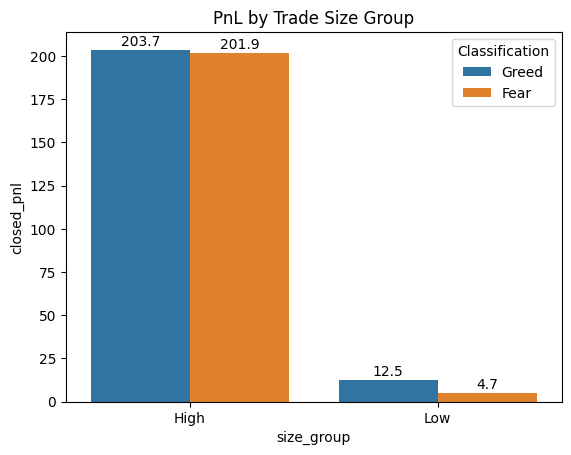

In [65]:
ax = sns.barplot(x='size_group', y='closed_pnl', hue='Classification', data=df, errorbar=None)

plt.title("PnL by Trade Size Group")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f',padding=1)

plt.show()

**Observation:**
Infrequent traders outperform frequent traders during Fear conditions, while frequent traders perform better during Greed.

**Interpretation:**
This suggests that infrequent traders make more selective, high-conviction trades during uncertain (Fear) markets, whereas frequent traders benefit more in active (Greed) markets due to higher participation.

# METHODOLOGY


- Cleaned and preprocessed both sentiment and trader datasets
- Standardized column names and handled missing values
- Converted timestamps and aligned datasets on a daily level
- Merged datasets to analyze trader behavior under different sentiment conditions
- Computed key metrics such as PnL, win rate, trade size, and trade direction
- Performed segmentation analysis based on trade size and trader frequency

# Key Insights & Strategy



**Key Insights**

1. Traders achieve higher average PnL during Fear despite lower win rates, indicating high-risk high-reward behavior.

2. Trade sizes are larger during Fear, suggesting traders make fewer but higher conviction trades.

3. Traders exhibit contrarian behavior by buying during Fear and selling during Greed.

4. Larger trades generate significantly higher returns, showing that high-conviction trades outperform smaller trades.

5. Infrequent traders outperform frequent traders during Fear, while frequent traders perform better during Greed.

**Strategy Recommendations**

1. During Fear periods, traders should focus on fewer, high-conviction trades with larger position sizes.

2. During Greed periods, traders should reduce position sizes and avoid overtrading to manage risk.

3. Infrequent traders should capitalize on Fear conditions, while frequent traders may perform better in Greed-driven markets.